# CARNOT ENGINE

 CARNOT CYCLE SIMULATOR ( '-_-' ) 
Enter Hot Reservoir Temperature T_hot (K) (example: 600): 620
Enter Cold Reservoir Temperature T_cold (K) (example: 300): 350
Enter Heat Input Q_in at T_hot (kJ) (example: 1000): 1400

CARNOT CYCLE SIMULATOR
From Thermodynamics Notes (Simplest Reversible Cycle)
T_hot (High Temperature) = 620.0 K
T_cold (Low Temperature) = 350.0 K
Heat Input (Q_in)  = 1400.0 kJ
Heat Rejected (Q_out) = 790.3 kJ
Net Work Output (W_net) = 609.7 kJ
Carnot Efficiency (η) = 43.55 %
Processes:
1-2 : Isothermal Expansion(Heat absorbed at T_hot)
2-3 : Reversible Adiabatic Expansion
3-4 : Isothermal Compression   (Heat rejected at T_cold)
4-1 : Reversible Adiabatic Compression


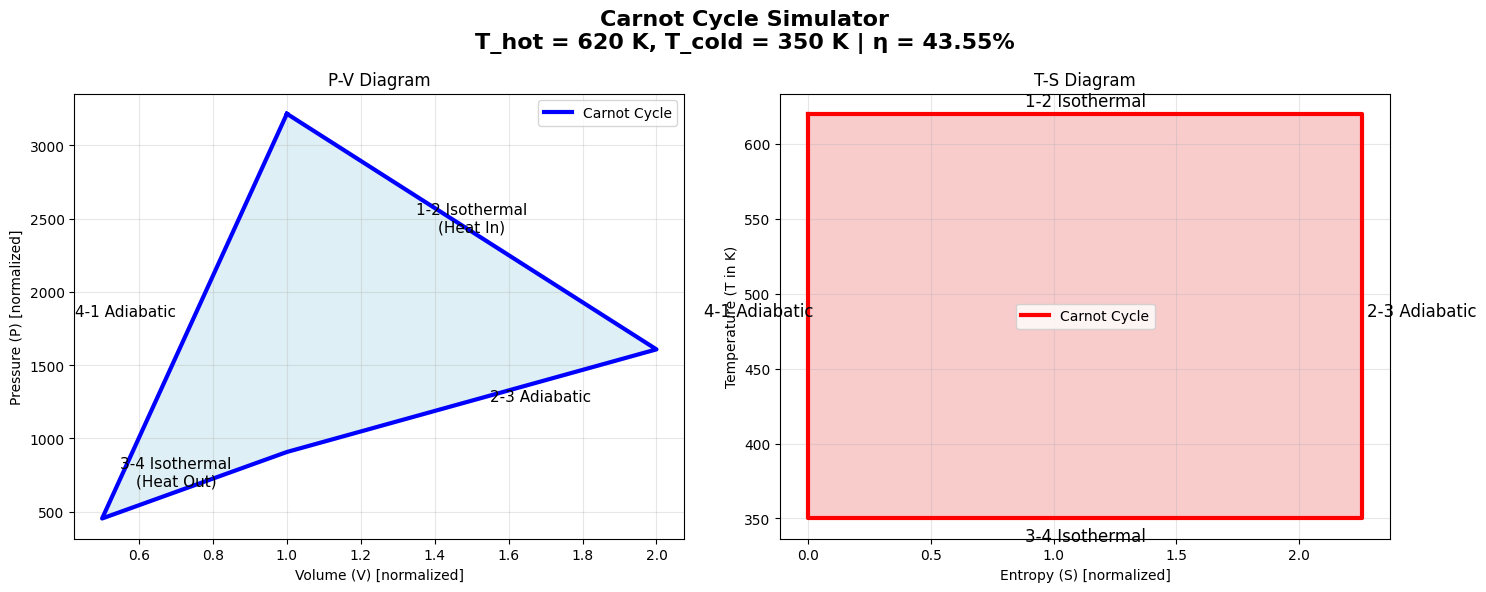

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== USER INPUTS ======================
print(" CARNOT CYCLE SIMULATOR ( '-_-' ) ")
T_hot = float(input("Enter Hot Reservoir Temperature T_hot (K) (example: 600): "))
T_cold = float(input("Enter Cold Reservoir Temperature T_cold (K) (example: 300): "))
Q_in = float(input("Enter Heat Input Q_in at T_hot (kJ) (example: 1000): "))

# Carnot Efficiency (from your thermodynamics notes)
eta = 1 - (T_cold / T_hot)
eta_percent = eta * 100

# Heat Rejected (Q_out)
Q_out = Q_in * (T_cold / T_hot)

# Net Work Output
W_net = Q_in - Q_out

# Normalized volumes for plotting (V1 > V2 > V3 > V4)
V1 = 1.0          # Start of isothermal expansion
V2 = 2.0
V3 = 1.0
V4 = 0.5

# Pressures using ideal gas relations (P V / T = constant)
P1 = Q_in / (V1 * (T_hot - T_cold)) * T_hot   # Arbitrary scaling for nice plot
P2 = P1 * (V1 / V2)
P3 = P2 * (T_cold / T_hot)
P4 = P3 * (V4 / V3)

print("\n" + "="*70)
print("CARNOT CYCLE SIMULATOR")
print("From Thermodynamics Notes (Simplest Reversible Cycle)")
print("="*70)
print(f"T_hot (High Temperature) = {T_hot:.1f} K")
print(f"T_cold (Low Temperature) = {T_cold:.1f} K")
print(f"Heat Input (Q_in)  = {Q_in:.1f} kJ")
print(f"Heat Rejected (Q_out) = {Q_out:.1f} kJ")
print(f"Net Work Output (W_net) = {W_net:.1f} kJ")
print(f"Carnot Efficiency (η) = {eta_percent:.2f} %")
print("="*70)
print("Processes:")
print("1-2 : Isothermal Expansion(Heat absorbed at T_hot)")
print("2-3 : Reversible Adiabatic Expansion")
print("3-4 : Isothermal Compression   (Heat rejected at T_cold)")
print("4-1 : Reversible Adiabatic Compression")

# ====================== PLOTS ======================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Carnot Cycle Simulator\n'
             f'T_hot = {T_hot:.0f} K, T_cold = {T_cold:.0f} K | η = {eta_percent:.2f}%',
             fontsize=16, fontweight='bold')

# ------------------- PV Diagram -------------------
V_pv = np.array([V1, V2, V3, V4, V1])
P_pv = np.array([P1, P2, P3, P4, P1])

ax1.plot(V_pv, P_pv, 'b-', linewidth=3, label='Carnot Cycle')
ax1.fill(V_pv, P_pv, 'lightblue', alpha=0.4)

# Label processes
ax1.text((V1+V2)/2, (P1+P2)/2 + 0.5, '1-2 Isothermal\n(Heat In)', ha='center', fontsize=11)
ax1.text((V2+V3)/2 + 0.05, (P2+P3)/2, '2-3 Adiabatic', ha='left', fontsize=11)
ax1.text((V3+V4)/2 - 0.05, (P3+P4)/2 - 0.5, '3-4 Isothermal\n(Heat Out)', ha='center', fontsize=11)
ax1.text((V4+V1)/2 - 0.05, (P4+P1)/2, '4-1 Adiabatic', ha='right', fontsize=11)

ax1.set_xlabel('Volume (V) [normalized]')
ax1.set_ylabel('Pressure (P) [normalized]')
ax1.set_title('P-V Diagram')
ax1.grid(True, alpha=0.3)
ax1.legend()

# ------------------- TS Diagram -------------------
# Entropy change (ΔS = Q/T for isothermal)
S_in = Q_in / T_hot
S_out = Q_out / T_cold

S = np.array([0, S_in, S_in, 0, 0])           # Normalized entropy
T = np.array([T_hot, T_hot, T_cold, T_cold, T_hot])

ax2.plot(S, T, 'r-', linewidth=3, label='Carnot Cycle')
ax2.fill(S, T, 'lightcoral', alpha=0.4)

# Labels
ax2.text(S_in/2, T_hot + 5, '1-2 Isothermal', ha='center', fontsize=12)
ax2.text(S_in + 0.02, (T_hot + T_cold)/2, '2-3 Adiabatic', ha='left', fontsize=12)
ax2.text(S_in/2, T_cold - 15, '3-4 Isothermal', ha='center', fontsize=12)
ax2.text(0.02, (T_hot + T_cold)/2, '4-1 Adiabatic', ha='right', fontsize=12)

ax2.set_xlabel('Entropy (S) [normalized]')
ax2.set_ylabel('Temperature (T in K)')
ax2.set_title('T-S Diagram')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()